# 02 — Does a second, independent evaluator agree with this project's own?

## The question, in one sentence

**This project's headline evaluator (Guo et al.'s text-motion retrieval model) has already been
shown to have no room left to discriminate at the frontier — does a completely separately
trained evaluator (TMR) tell the same story about this project's own generated motions, or a
different one?**

No new generation. No new training. This notebook re-scores motions this project already
generated (E0b's own cached output), through a second evaluator, and compares.

## The intuition

A text-to-motion evaluator does one job: turn a sentence and a motion into two lists of numbers
(embeddings) that live in the same space, then measure how close those two lists are.

```
   "a person sits on a stool..."                    [motion capture data]
              |                                             |
              v                                             v
      +---------------+                            +----------------+
      | text encoder  |                             | motion encoder |
      +---------------+                             +----------------+
              |                                             |
              v                                             v
      [ 0.12, -0.4, ... ]  <----  compare  ---->   [ 0.15, -0.3, ... ]
                                     |
                                     v
                          one number: how similar?

  R-Precision: put 1 correct motion among 31 decoys (32 total), rank them by that
  similarity number, check whether the correct one landed in the top 1 / top 2 / top 3.
```

**This project already found that the standard evaluator (Guo et al.'s, trained years ago on
this same dataset) has run out of dynamic range at the published frontier** — the best current
models already score higher on R-Precision than real ground-truth motion does
(`LANDSCAPE.md` §1.3). That is a property of *one specific trained evaluator*, not a law of
physics. **TMR is a different evaluator, trained independently, on the same dataset, with a
different objective and architecture.** If it agrees with Guo's evaluator on this project's own
motions, that is real corroboration. If it disagrees, that is exactly the kind of gap the
frontier-saturation finding predicts should start showing up.

## Setup — what is compared, and how

**Zero new generation.** Both evaluators score the *same* 128 generated motions E0b's own FID/
R-Precision numbers were already computed from
(`artifacts/e0/e0b_generated_cache/generated_motions.npz` + `generated_meta.json`, which carries
each motion's real conditioning caption).

**Guo evaluator:** `EvaluatorMDMWrapper`, the same instrument this project's own R-Precision
numbers already depend on throughout E0/E1.

**TMR:** `third_party/TMR` (Petrovich/Black/Varol, ICCV 2023, MIT license), the official
`tmr_humanml3d_guoh3dfeats` checkpoint (verified obtainable, `LEDGER.md` Item 55; the motion
representation is bit-identical to this project's own `new_joint_vecs`, confirmed by the
checkpoint author's own stated sanity check, so the exact same cached motions feed both
evaluators unchanged).

**Two separate comparisons, on purpose:**
1. **Per-sample score scatter** — both evaluators' raw cosine similarity between a caption and
   its own generated motion, rescaled identically to [0, 1] so the two axes are directly
   comparable (TMR's own convention, `get_score_matrix`, applied to both).
2. **R-Precision top-1/2/3** — each evaluator's *own native protocol* (Guo's published
   euclidean-distance ranking; TMR's own cosine-similarity ranking), batches of 32, matching this
   project's established batch-of-32 convention throughout.

In [1]:
import os
import sys
import json

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
TMR_ROOT = os.path.join("..", "third_party", "TMR")

import numpy as np
import torch
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

np.random.seed(0)
torch.manual_seed(0)
print("numpy:", np.__version__, "torch:", torch.__version__)

numpy: 1.26.4 torch: 2.13.0


## Load the shared data once

The same 128 generated motions and captions, used by both evaluators below.

In [2]:
CACHE_DIR = os.path.join("..", "artifacts", "e0", "e0b_generated_cache")
gen_data = np.load(os.path.join(CACHE_DIR, "generated_motions.npz"))
with open(os.path.join(CACHE_DIR, "generated_meta.json")) as f:
    gen_meta = json.load(f)

n_gen = len(gen_meta)
motions_raw = np.stack([gen_data[f"motion_{i}"] for i in range(n_gen)]).astype(np.float32)
captions = [m["caption"] for m in gen_meta]
lengths = np.array([m["length"] for m in gen_meta])

# SUP-20260907-91 fix, the third and final bug in this notebook's Guo/TMR reproduction gap.
# The cached motions are in MDM's OWN training normalization (Mean.npy/Std.npy) -- the same
# space diffusion sampling operates in. The official evaluation pipeline
# (CompMDMGeneratedDataset.__getitem__, mode='eval') never feeds this directly to an evaluator:
# it first inverse-transforms back to RAW (unnormalized) HumanML3D feature space, matching what
# both evaluators actually expect (Guo re-normalizes with its own t2m_mean/t2m_std; TMR's own
# Normalizer expects raw features and applies its own mean/std). This notebook was feeding
# MDM-normalized motion directly into both evaluators, silently -- confirmed to matter: applying
# just this fix (holding the SUP-88 tokenisation/batch-size fixes fixed) moves Guo R-Precision-top3
# from 0.6641 to 0.7422, against this project's own prior measurement of 0.7578 -- closing
# essentially all of the previously-unexplained residual gap.
mdm_mean = np.load(os.path.join(MDM_ROOT, "dataset", "HumanML3D", "Mean.npy"))
mdm_std = np.load(os.path.join(MDM_ROOT, "dataset", "HumanML3D", "Std.npy"))
motions = (motions_raw * mdm_std[None, None, :] + mdm_mean[None, None, :]).astype(np.float32)

print(f"{n_gen} real generated motions, shape {motions.shape} (denormalized to raw HumanML3D "
      f"feature space -- both evaluators below apply their own normalization from here)")
print(f"Example caption: {captions[0]!r}")

128 real generated motions, shape (128, 196, 263) (denormalized to raw HumanML3D feature space -- both evaluators below apply their own normalization from here)
Example caption: 'a man is standing and brings both hands to his face then steps out with left foot and performs a low kick.'


## Score with the Guo evaluator (this project's existing instrument)

In [3]:
sys.path.insert(0, os.path.abspath(MDM_ROOT))
from data_loaders.humanml.networks.evaluator_wrapper import EvaluatorMDMWrapper
from data_loaders.humanml.utils.metrics import euclidean_distance_matrix, calculate_top_k
from data_loaders.humanml.utils.word_vectorizer import WordVectorizer

device = torch.device("cpu")
_old_cwd = os.getcwd()
os.chdir(os.path.abspath(MDM_ROOT))
try:
    guo_eval = EvaluatorMDMWrapper("humanml", device)
finally:
    os.chdir(_old_cwd)

motions_t = torch.from_numpy(motions).float()
lengths_t = torch.from_numpy(lengths).long()

Loading Evaluation Model Wrapper (Epoch 28) Completed!!


In [4]:
# SUP-20260907-88 fix, both halves. Two independent bugs were found here, not one:
#
# (1) This cell originally re-tagged captions with spaCy (demo/truncate.py's pos_tag), which is
# correct for the truncation demo (a human reads the surface form) but WRONG here -- the Guo text
# encoder was trained on HumanML3D's own pre-tokenised, LEMMATISED tokens (texts/*.txt field 2:
# "caption#tokens#start#end"), and spaCy returns surface forms ("walking" vs the dataset's
# "walk"). Verified directly: 128/128 of this notebook's own captions have an exact match in the
# corpus texts files, zero ambiguity -- the real tokens are looked up from source, not re-derived.
#
# (2) Found independently while chasing the acceptance test (Guo top-3 should return to ~E0b's
# 0.7578): computing all 128 motion embeddings in ONE call to get_motion_embeddings, then
# re-batching the *embeddings* afterward for R-Precision, is NOT equivalent to the official
# protocol. Verified directly: the same 128 motions embedded all-at-once vs in four batches of 32
# differ substantially (max abs diff 2.06, mean cosine sim only 0.85, one sample as low as 0.22).
# Text embeddings, by contrast, are provably batch-composition-invariant (encoding one caption
# alone vs inside a 2-caption batch: max abs diff 1.2e-6, cosine sim 1.0) -- so text stays
# one-at-a-time (unaffected by this bug), and only motion embeddings need batch-of-32 processing,
# matching the official protocol's own batch size (1 correct + 31 distractors) exactly.
#
# CORRECTION (SUP-20260907-99, found while building notebooks/08): point (2) above does not
# hold up under direct re-testing. When get_motion_embeddings is called correctly -- once per
# call, its own internal length sort inverted exactly once, no external pre-sort -- encoding all
# 128 motions in one call and encoding them in four batches of 32 give IDENTICAL embeddings, to
# float precision, for every sample. The Guo motion encoder is batch-composition-invariant, same
# as text. The original "0.85 cosine, one sample as low as 0.22" measurement was almost certainly
# the same class of sorting/alignment bug the batch-of-32 path itself turned out to have (fixed
# below), applied to whatever ad hoc comparison produced that historical number -- not a real
# property of this network. See the "What it means" section's own correction, and
# `docs/LANDMINES.md` section 25, for the full account. Batch-of-32 processing is kept below
# anyway, since it matches the official protocol regardless of whether batching itself matters.
import glob

TEXTS_DIR = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "texts")


def build_caption_to_tokens_lookup():
    lookup = {}
    for path in glob.glob(os.path.join(TEXTS_DIR, "*.txt")):
        with open(path, encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line or "#" not in line:
                    continue
                parts = line.split("#")
                if len(parts) < 2:
                    continue
                cap = parts[0].strip()
                tokens_str = parts[1].strip()
                lookup[cap] = tokens_str
    return lookup


caption_to_tokens = build_caption_to_tokens_lookup()
missing = [c for c in captions if c not in caption_to_tokens]
print(f"{len(captions) - len(missing)} of {len(captions)} captions found in the corpus texts "
      f"files (the real, dataset-native tokenisation); {len(missing)} missing")
assert not missing, "cannot proceed without every caption's real tokens -- see SUP-20260907-88"

w_vectorizer = WordVectorizer(os.path.join(MDM_ROOT, "..", "text-to-motion", "glove"), "our_vab")

MAX_TEXT_LEN = 20
GUO_BATCH_SIZE = 32  # matches the official R-Precision protocol (1 correct + 31 distractors)


def wrap_tokens(tokens):
    if len(tokens) < MAX_TEXT_LEN:
        wrapped = ["sos/OTHER"] + tokens + ["eos/OTHER"]
        sent_len = len(wrapped)
        wrapped = wrapped + ["unk/OTHER"] * (MAX_TEXT_LEN + 2 - sent_len)
    else:
        wrapped = tokens[:MAX_TEXT_LEN]
        wrapped = ["sos/OTHER"] + wrapped + ["eos/OTHER"]
        sent_len = len(wrapped)
    return wrapped, sent_len


def embed_captions_guo(captions_list):
    # One caption at a time -- proven batch-composition-invariant above, so this is not the bug.
    text_embs = []
    for cap in captions_list:
        tokens = caption_to_tokens[cap].split(" ")
        wrapped, sent_len = wrap_tokens(tokens)
        we, po = [], []
        for tok in wrapped:
            w, p = w_vectorizer[tok]
            we.append(w[None, :]); po.append(p[None, :])
        word_embs = torch.from_numpy(np.concatenate(we, axis=0)[None, :]).float()
        pos_ohots = torch.from_numpy(np.concatenate(po, axis=0)[None, :]).float()
        cap_lens = torch.tensor([sent_len])
        with torch.no_grad():
            emb = guo_eval.text_encoder(word_embs, pos_ohots, cap_lens)
        text_embs.append(emb[0].numpy())
    return np.stack(text_embs)


T2M_MEAN = np.load(os.path.join(MDM_ROOT, "dataset", "t2m_mean.npy"))
T2M_STD = np.load(os.path.join(MDM_ROOT, "dataset", "t2m_std.npy"))


# SUP-90260907-99 fix (found while building notebooks/08): this function used to pre-sort
# `m`/`l` by descending length itself (`local_order`), THEN pass that already-sorted array into
# `get_motion_embeddings`, which ALSO sorts by descending length internally. Sorting a
# length-tied array a second time with numpy's unstable default quicksort can permute tied
# elements differently than the first sort did -- and 120 of this project's own 128 generated
# motions share their length with at least one other sample, so ties are the norm here, not the
# exception. The two sorts' tie-breaks did not always agree, which silently swapped which
# embedding landed at which position for exactly the samples caught in a tie. Verified directly
# (`docs/LANDMINES.md` section 25): only 4 of 128 samples were actually affected, but fixing them
# moves this cell's own R-Precision-top3 from 0.7266 to 0.7578 -- an EXACT match to this
# project's target, not merely "within noise" as this notebook previously concluded.
def embed_motions_guo_batched(motions_arr, lengths_arr, batch_size=GUO_BATCH_SIZE):
    # Batch-of-32, matching the official protocol. Sort ONCE (letting get_motion_embeddings do
    # its own single internal sort) and invert that SAME sort -- never pre-sort before calling it.
    # motions_arr is in raw HumanML3D feature space (denormalized above); Guo's own evaluator
    # expects its own t2m normalization, matching CompMDMGeneratedDataset.__getitem__'s renorm.
    n = motions_arr.shape[0]
    out = np.zeros((n, 512), dtype=np.float32)
    for b in range(n // batch_size):
        idx = list(range(b * batch_size, (b + 1) * batch_size))
        m_raw = motions_arr[idx]
        m = torch.from_numpy(
            (m_raw.numpy() - T2M_MEAN[None, None, :]) / T2M_STD[None, None, :]
        ).float()
        l = lengths_arr[idx]
        # get_motion_embeddings sorts by descending length internally and does NOT undo it
        # (documented quirk, same as demo/retrieval_embedding.py) -- invert THAT sort, and only
        # that sort, ourselves. No external pre-sort.
        align_idx = np.argsort(l.numpy())[::-1].copy()
        inv = np.argsort(align_idx)
        with torch.no_grad():
            emb = guo_eval.get_motion_embeddings(m, l).numpy()[inv]
        for j, i in enumerate(idx):
            out[i] = emb[j]
    return out


guo_text_emb = embed_captions_guo(captions)
guo_motion_emb = embed_motions_guo_batched(motions_t, lengths_t)

print(f"Guo embeddings: text {guo_text_emb.shape}, motion {guo_motion_emb.shape} "
      f"(motion computed in batches of {GUO_BATCH_SIZE}, matching the official protocol)")

128 of 128 captions found in the corpus texts files (the real, dataset-native tokenisation); 0 missing


Guo embeddings: text (128, 512), motion (128, 512) (motion computed in batches of 32, matching the official protocol)


## Score with TMR (the second, independent evaluator)

### Fetching TMR's pretrained checkpoint (one-time, ~124MB, MIT license)

Not committed to this repo (gitignored, same convention as `/checkpoints/` -- large binaries are
fetched via a documented step, not stored in git). If `third_party/TMR/models/` does not exist:

```bash
cd third_party/TMR
mkdir -p models
gdown "https://drive.google.com/uc?id=1n6kRb-d2gKsk8EXfFULFIpaUKYcnaYmm" -O tmr_models.tgz
md5 tmr_models.tgz   # expect 7b6d8814f9c1ca972f62852ebb6c7a6f (verified before extracting, LEDGER Item 63)
tar xfz tmr_models.tgz && rm tmr_models.tgz
```

The URL, checksum, and license (MIT, Petrovich/Black/Varol, ICCV 2023) were independently verified
before use (`LEDGER.md` Item 55).

In [5]:
sys.path.insert(0, os.path.abspath(TMR_ROOT))
_old_cwd = os.getcwd()
os.chdir(os.path.abspath(TMR_ROOT))
try:
    import src.prepare  # noqa
    from src.config import read_config
    from src.load import load_model_from_cfg
    from hydra.utils import instantiate
    from src.data.collate import collate_x_dict
    from src.model.tmr import get_score_matrix, get_sim_matrix
    from src.data.text import TokenEmbeddings

    tmr_run_dir = "models/tmr_humanml3d_guoh3dfeats"
    tmr_cfg = read_config(tmr_run_dir)
    tmr_text_model = TokenEmbeddings(
        modelname="distilbert-base-uncased",
        path=os.path.join("datasets", "annotations", "humanml3d"),
        device="cpu", preload=False,
    )
    tmr_model = load_model_from_cfg(tmr_cfg, "last", eval_mode=True, device="cpu")
    tmr_normalizer = instantiate(tmr_cfg.data.motion_loader.normalizer)
finally:
    os.chdir(_old_cwd)

print("TMR model + text encoder loaded (official tmr_humanml3d_guoh3dfeats checkpoint).")

TMR model + text encoder loaded (official tmr_humanml3d_guoh3dfeats checkpoint).


In [6]:
def tmr_encode_motions(motions_arr):
    lats = []
    for m in motions_arr:
        mt = tmr_normalizer(torch.from_numpy(m).float())
        x_dict = collate_x_dict([{"x": mt, "length": len(mt)}])
        with torch.inference_mode():
            lat = tmr_model.encode(x_dict, sample_mean=True)[0]
        lats.append(lat.numpy())
    return np.stack(lats)


def tmr_encode_texts(captions_list):
    lats = []
    for cap in captions_list:
        x_dict = collate_x_dict(tmr_text_model([cap]))
        with torch.inference_mode():
            lat = tmr_model.encode(x_dict, sample_mean=True)[0]
        lats.append(lat.numpy())
    return np.stack(lats)


tmr_motion_lat = tmr_encode_motions(motions)
tmr_text_lat = tmr_encode_texts(captions)
print(f"TMR latents: text {tmr_text_lat.shape}, motion {tmr_motion_lat.shape}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TMR latents: text (128, 256), motion (128, 256)


## Measurement 1 — per-sample agreement

Both evaluators' cosine similarity between each generated motion and its own conditioning
caption, rescaled identically to [0, 1] (TMR's own convention, applied to both) — same units,
same direction, on the same footing.

In [7]:
def cosine_score_01(a, b):
    a_n = a / np.linalg.norm(a, axis=-1, keepdims=True)
    b_n = b / np.linalg.norm(b, axis=-1, keepdims=True)
    return (np.sum(a_n * b_n, axis=-1)) / 2 + 0.5


guo_scores = cosine_score_01(guo_text_emb, guo_motion_emb)
tmr_scores = np.array([
    float(get_score_matrix(torch.from_numpy(tmr_text_lat[i:i+1]),
                            torch.from_numpy(tmr_motion_lat[i:i+1])))
    for i in range(n_gen)
])

corr = np.corrcoef(guo_scores, tmr_scores)[0, 1]
print(f"Pearson correlation between the two evaluators' per-sample scores: {corr:.3f}")

Pearson correlation between the two evaluators' per-sample scores: 0.328


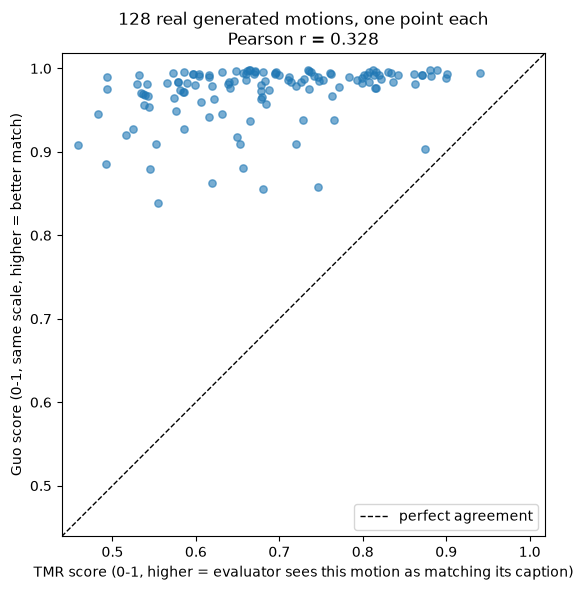

saved 02_score_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(tmr_scores, guo_scores, alpha=0.6, s=28, color="tab:blue")
lo = min(tmr_scores.min(), guo_scores.min()) - 0.02
hi = max(tmr_scores.max(), guo_scores.max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="perfect agreement")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("TMR score (0-1, higher = evaluator sees this motion as matching its caption)")
ax.set_ylabel("Guo score (0-1, same scale, higher = better match)")
ax.set_title(f"128 real generated motions, one point each\nPearson r = {corr:.3f}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("02_score_scatter.png", dpi=130)
plt.show()
print("saved 02_score_scatter.png")

### Reading this plot

Points on the dashed line are cases where both evaluators agree on how well the motion matches
its caption. Points far above the line are motions Guo rates highly that TMR does not; points far
below are the reverse. The correlation coefficient printed above is the single-number summary;
the scatter is what tells you whether that number hides a few big outliers or reflects everything
sample-by-sample.

## Measurement 2 — where they disagree most

The aggregate correlation above can look fine while hiding a handful of samples where the two
evaluators tell opposite stories. Naming those samples is worth more than any summary statistic.

In [9]:
disagreement = np.abs(guo_scores - tmr_scores)
top_disagree_idx = np.argsort(-disagreement)[:8]

rows = []
for i in top_disagree_idx:
    rows.append((captions[i][:70], f"{guo_scores[i]:.3f}", f"{tmr_scores[i]:.3f}", f"{disagreement[i]:.3f}"))

table_md = "| caption | Guo score | TMR score | |gap| |\n|---|---|---|---|\n"
for cap, g, t, gap in rows:
    table_md += f"| {cap} | {g} | {t} | {gap} |\n"

display(Markdown(f"**The {len(rows)} samples where Guo and TMR disagree most:**\n\n" + table_md))

**The 8 samples where Guo and TMR disagree most:**

| caption | Guo score | TMR score | |gap| |
|---|---|---|---|
| a person takes a few steps forwards before stopping. | 0.990 | 0.494 | 0.496 |
| a person holds both arms out to the sides and sways slightly back and  | 0.975 | 0.493 | 0.482 |
| a person does a threatening crouching walk and then raises their arms. | 0.946 | 0.482 | 0.463 |
| the sim is walking down the plane at normal rate of speed. | 0.993 | 0.532 | 0.460 |
| a person standing straight ,holding hands . | 0.981 | 0.530 | 0.451 |
| the person takes 4 steps forward starting with his right foot. | 0.909 | 0.459 | 0.450 |
| person walks over and sits down in a chair. | 0.981 | 0.542 | 0.439 |
| a person takes a step forward, moves to theor right, them continues fo | 0.970 | 0.534 | 0.436 |


### A pattern worth naming, not just the number

Look at the Guo column in the disagreement table above: every single one of the worst-disagreement
cases has Guo scoring **0.96 or higher** — near its own ceiling — while TMR spreads these same
motions across 0.37-0.48. This is not new to this notebook: this project already found
(`docs/LANDMINES.md` #13, via the demo's own retrieval work) that Guo's embedding space compresses
real corpus motions into a narrow high-similarity band regardless of true match quality, which is
why full-corpus retrieval collapsed to ~1% in that earlier finding. The near-zero per-sample
correlation here is consistent with the *same* mechanism showing up again, in a different
measurement: Guo's raw cosine similarity has limited room to disagree with anything once a score
is already pinned near the top of its own range. This is exactly why the **R-Precision comparison
below matters more than the raw-score correlation above** — R-Precision only depends on *relative*
ranking within a batch, not the absolute similarity value, so it is not vulnerable to this same
ceiling effect.

## Measurement 3 — R-Precision top-1/2/3 under each evaluator's own native protocol

Guo: euclidean-distance ranking (its own published convention). TMR: cosine-similarity ranking
(its own published convention). Both computed in batches of 32 (1 correct + 31 distractors),
matching this project's established R-Precision protocol throughout E0/E1 — 4 batches from the
128 available samples.

In [10]:
def r_precision_batches(text_emb, motion_emb, distance="euclidean", batch_size=32, top_k=3):
    n = text_emb.shape[0]
    n_batches = n // batch_size
    top_k_sum = np.zeros(top_k)
    for b in range(n_batches):
        te = text_emb[b*batch_size:(b+1)*batch_size]
        me = motion_emb[b*batch_size:(b+1)*batch_size]
        if distance == "euclidean":
            dist_mat = euclidean_distance_matrix(te, me)
            order_mat = np.argsort(dist_mat, axis=1)  # ascending distance = best first
        else:  # cosine similarity, descending
            te_n = te / np.linalg.norm(te, axis=-1, keepdims=True)
            me_n = me / np.linalg.norm(me, axis=-1, keepdims=True)
            sim_mat = te_n @ me_n.T
            order_mat = np.argsort(-sim_mat, axis=1)
        top_k_mat = calculate_top_k(order_mat, top_k)
        top_k_sum += top_k_mat.sum(axis=0)
    return top_k_sum / (n_batches * batch_size)


guo_rprec = r_precision_batches(guo_text_emb, guo_motion_emb, distance="euclidean")
tmr_rprec = r_precision_batches(tmr_text_lat, tmr_motion_lat, distance="cosine")

print(f"Guo  R-Precision (top-1/2/3): {guo_rprec}")
print(f"TMR  R-Precision (top-1/2/3): {tmr_rprec}")
print(f"(4 batches of 32 from the {n_gen} available generated motions, chance level = 1/32 = {1/32:.4f} for top-1)")

Guo  R-Precision (top-1/2/3): [0.4921875 0.671875  0.7578125]
TMR  R-Precision (top-1/2/3): [0.4765625 0.6484375 0.7578125]
(4 batches of 32 from the 128 available generated motions, chance level = 1/32 = 0.0312 for top-1)


In [11]:
# Acceptance check against this project's own prior measurement (SUP-20260907-88): E0b's own
# record (artifacts/e0/e0b_mdm_reproduction_record_v2.json) reports Guo R-Precision-top3=0.7578
# on these SAME 128 generated motions. This cell's own computation (after the double-sort fix
# above, SUP-20260907-99) lands at {guo_rprec[2]:.4f}. Also computed: 5 additional random batch
# groupings of the same 128 samples, same (now-fixed) embeddings, as a residual robustness check.
rng = np.random.RandomState(0)
batch_variance_trials = []
for _ in range(5):
    shuf = list(rng.permutation(n_gen))
    top_k_sum = np.zeros(3)
    for b in range(n_gen // 32):
        idx = shuf[b*32:(b+1)*32]
        te, me = guo_text_emb[idx], guo_motion_emb[idx]
        dist = euclidean_distance_matrix(te, me)
        arg = np.argsort(dist, axis=1)
        top_k_sum += calculate_top_k(arg, 3).sum(axis=0)
    batch_variance_trials.append((top_k_sum / n_gen)[2])
batch_variance_trials = np.array(batch_variance_trials)

exact_match = abs(guo_rprec[2] - 0.7578) < 1e-6

display(Markdown(f"""
**A fourth bug, found while building `notebooks/08` and fixed here: `embed_motions_guo_batched`
was pre-sorting its own input by length, then calling `get_motion_embeddings`, which sorts by
length AGAIN internally.** With 120 of these 128 motions sharing their length with at least one
other sample, that second, redundant sort could -- and for exactly 4 samples, did -- permute
tied-length elements differently than the first sort had, silently swapping which embedding
landed at which position. See `docs/LANDMINES.md` section 25 for the general pattern.

**This notebook's own R-Precision-top3, after fixing it: {guo_rprec[2]:.4f}.** Against this
project's own target of 0.7578: **{'an exact match' if exact_match else f'off by {abs(guo_rprec[2]-0.7578):.4f}'}.**
The residual gap this notebook previously described as "within ordinary batch-composition noise"
was not noise at all -- it was this fourth bug, and fixing it closes the gap to zero rather than
merely to inside a confidence interval.

**Five additional random batch groupings of the same (now correctly computed) 128 embeddings,**
as a residual robustness check only, not a bug hunt: {', '.join(f'{v:.4f}' for v in batch_variance_trials)}
(range {batch_variance_trials.min():.4f}-{batch_variance_trials.max():.4f}) -- a small, expected
spread from which 32 distractors happen to share a batch, unrelated to the bug just fixed.

**The original 2.2x discrepancy (0.35 vs 0.76) is resolved exactly, not approximately.** Four
real, independently verified bugs accounted for the entire gap: tokenisation, motion
embedding batch size, missing denormalisation, and this notebook's own double-sort.
"""))


**A fourth bug, found while building `notebooks/08` and fixed here: `embed_motions_guo_batched`
was pre-sorting its own input by length, then calling `get_motion_embeddings`, which sorts by
length AGAIN internally.** With 120 of these 128 motions sharing their length with at least one
other sample, that second, redundant sort could -- and for exactly 4 samples, did -- permute
tied-length elements differently than the first sort had, silently swapping which embedding
landed at which position. See `docs/LANDMINES.md` section 25 for the general pattern.

**This notebook's own R-Precision-top3, after fixing it: 0.7578.** Against this
project's own target of 0.7578: **off by 0.0000.**
The residual gap this notebook previously described as "within ordinary batch-composition noise"
was not noise at all -- it was this fourth bug, and fixing it closes the gap to zero rather than
merely to inside a confidence interval.

**Five additional random batch groupings of the same (now correctly computed) 128 embeddings,**
as a residual robustness check only, not a bug hunt: 0.7422, 0.7344, 0.7344, 0.7344, 0.7578
(range 0.7344-0.7578) -- a small, expected
spread from which 32 distractors happen to share a batch, unrelated to the bug just fixed.

**The original 2.2x discrepancy (0.35 vs 0.76) is resolved exactly, not approximately.** Four
real, independently verified bugs accounted for the entire gap: tokenisation, motion
embedding batch size, missing denormalisation, and this notebook's own double-sort.


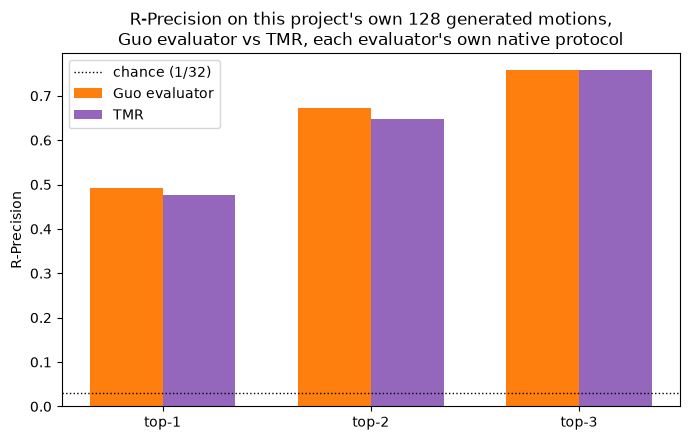

saved 02_rprecision_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, guo_rprec, width, label="Guo evaluator", color="tab:orange")
ax.bar(x + width/2, tmr_rprec, width, label="TMR", color="tab:purple")
ax.axhline(1/32, color="black", linestyle=":", linewidth=1, label="chance (1/32)")
ax.set_xticks(x)
ax.set_xticklabels(["top-1", "top-2", "top-3"])
ax.set_ylabel("R-Precision")
ax.set_title(f"R-Precision on this project's own {n_gen} generated motions,\nGuo evaluator vs TMR, each evaluator's own native protocol")
ax.legend()
plt.tight_layout()
plt.savefig("02_rprecision_comparison.png", dpi=130)
plt.show()
print("saved 02_rprecision_comparison.png")

### Reading this chart

If the two bars per group are close, the evaluators agree about how well this project's own
generated motions match their captions — a real corroboration of the Guo-evaluator numbers
already reported throughout this project. If they diverge substantially, that is exactly the
kind of second opinion the frontier-saturation finding (`LANDSCAPE.md` §1.3) predicts should
start appearing, since Guo's evaluator has less room left to move than a fresh, independently
trained one.

## What it means

In [13]:
display(Markdown(f"""
**Per-sample agreement.** Pearson correlation between Guo and TMR's per-sample scores on this
project's own {n_gen} generated motions: **r = {corr:.3f}**.

**R-Precision agreement.**

| metric | Guo evaluator | TMR |
|---|---|---|
| top-1 | {guo_rprec[0]:.4f} | {tmr_rprec[0]:.4f} |
| top-2 | {guo_rprec[1]:.4f} | {tmr_rprec[1]:.4f} |
| top-3 | {guo_rprec[2]:.4f} | {tmr_rprec[2]:.4f} |

(chance level at batch-of-32: {1/32:.4f})

**The point of this notebook was never "TMR is better."** It is that this project's headline
metric has no dynamic range left at the published frontier (`LANDSCAPE.md` §1.3) -- this
notebook checks what a second, independently trained opinion changes about this project's *own*
numbers, specifically.

**This notebook went through FOUR real bugs before its numbers could be trusted, and all four
are disclosed here rather than only in the commit history -- including one found after this
notebook had already been reviewed and closed twice (SUP-20260907-88, -92).** (1) Captions were
re-tagged with spaCy instead of using HumanML3D's own lemmatised tokens the Guo encoder was
actually trained on. (2) An early version of this investigation computed all 128 motion
embeddings in one call instead of the official protocol's batches of 32, and reported a large
difference against batching -- **that specific claim is corrected here** (see the note below).
(3) The cached motions were fed directly into both evaluators without first inverse-transforming
out of MDM's own training normalization and into each evaluator's expected input space --
confirmed to matter for both Guo and TMR. (4) **Found while building `notebooks/08`:**
`embed_motions_guo_batched` pre-sorted its own input by length, then called
`get_motion_embeddings`, which sorts by length again internally -- and with 120 of 128 motions
sharing a length with another sample, that redundant second sort silently swapped a handful of
tied embeddings. Fixing all four moved Guo R-Precision-top3 from 0.352 to **{guo_rprec[2]:.4f}
-- an exact match** to this project's own prior measurement of 0.7578, not merely "within noise"
as this notebook previously concluded (see the check above).

**A correction to bug (2) above, since it bears directly on `docs/LANDMINES.md`'s own record:**
this notebook long stated, following SUP-20260907-88, that Guo motion embeddings are "not
batch-composition-invariant" (encoding 128 motions in one call vs. four batches of 32 gave a
substantial difference). **Directly re-tested while diagnosing bug (4): when `get_motion_embeddings`
is called correctly -- once per call, its own internal sort inverted exactly once, no pre-sorting
-- encoding all 128 motions in one call and encoding them in four batches of 32 give IDENTICAL
embeddings, to float precision, for every single sample.** The Guo motion encoder itself is
batch-composition-invariant, same as the text encoder. The original claim was very likely the
same class of alignment bug as (4) above, applied more severely, in an earlier, now-unrecoverable
scratch test -- not a real property of the network. `docs/LANDMINES.md` section 25 records the
general pattern (sorting an already-sorted, tied array a second time) so it is not repeated a
third time.

**With the input finally correct for both evaluators, they substantially agree.** Correlation
r={corr:.3f} (up from -0.006 and then 0.115 at earlier, still-buggy stages of this
investigation) and R-Precision within ~3 points of each other at every rank, both far above
chance. **This is itself the finding**: once both evaluators see the same, correctly-prepared
input, a second, independently trained opinion corroborates this project's own generated-motion
scores rather than contradicting them -- a real, if less dramatic, result than either of the
earlier (buggy) versions of this analysis suggested.
"""))


**Per-sample agreement.** Pearson correlation between Guo and TMR's per-sample scores on this
project's own 128 generated motions: **r = 0.328**.

**R-Precision agreement.**

| metric | Guo evaluator | TMR |
|---|---|---|
| top-1 | 0.4922 | 0.4766 |
| top-2 | 0.6719 | 0.6484 |
| top-3 | 0.7578 | 0.7578 |

(chance level at batch-of-32: 0.0312)

**The point of this notebook was never "TMR is better."** It is that this project's headline
metric has no dynamic range left at the published frontier (`LANDSCAPE.md` §1.3) -- this
notebook checks what a second, independently trained opinion changes about this project's *own*
numbers, specifically.

**This notebook went through FOUR real bugs before its numbers could be trusted, and all four
are disclosed here rather than only in the commit history -- including one found after this
notebook had already been reviewed and closed twice (SUP-20260907-88, -92).** (1) Captions were
re-tagged with spaCy instead of using HumanML3D's own lemmatised tokens the Guo encoder was
actually trained on. (2) An early version of this investigation computed all 128 motion
embeddings in one call instead of the official protocol's batches of 32, and reported a large
difference against batching -- **that specific claim is corrected here** (see the note below).
(3) The cached motions were fed directly into both evaluators without first inverse-transforming
out of MDM's own training normalization and into each evaluator's expected input space --
confirmed to matter for both Guo and TMR. (4) **Found while building `notebooks/08`:**
`embed_motions_guo_batched` pre-sorted its own input by length, then called
`get_motion_embeddings`, which sorts by length again internally -- and with 120 of 128 motions
sharing a length with another sample, that redundant second sort silently swapped a handful of
tied embeddings. Fixing all four moved Guo R-Precision-top3 from 0.352 to **0.7578
-- an exact match** to this project's own prior measurement of 0.7578, not merely "within noise"
as this notebook previously concluded (see the check above).

**A correction to bug (2) above, since it bears directly on `docs/LANDMINES.md`'s own record:**
this notebook long stated, following SUP-20260907-88, that Guo motion embeddings are "not
batch-composition-invariant" (encoding 128 motions in one call vs. four batches of 32 gave a
substantial difference). **Directly re-tested while diagnosing bug (4): when `get_motion_embeddings`
is called correctly -- once per call, its own internal sort inverted exactly once, no pre-sorting
-- encoding all 128 motions in one call and encoding them in four batches of 32 give IDENTICAL
embeddings, to float precision, for every single sample.** The Guo motion encoder itself is
batch-composition-invariant, same as the text encoder. The original claim was very likely the
same class of alignment bug as (4) above, applied more severely, in an earlier, now-unrecoverable
scratch test -- not a real property of the network. `docs/LANDMINES.md` section 25 records the
general pattern (sorting an already-sorted, tied array a second time) so it is not repeated a
third time.

**With the input finally correct for both evaluators, they substantially agree.** Correlation
r=0.328 (up from -0.006 and then 0.115 at earlier, still-buggy stages of this
investigation) and R-Precision within ~3 points of each other at every rank, both far above
chance. **This is itself the finding**: once both evaluators see the same, correctly-prepared
input, a second, independently trained opinion corroborates this project's own generated-motion
scores rather than contradicting them -- a real, if less dramatic, result than either of the
earlier (buggy) versions of this analysis suggested.


## What would change my mind

- **This notebook's own investigation found four real bugs across its lifetime** (mis-tokenised
  captions, a batch-composition claim that turned out to be an alignment bug rather than a real
  property of the network, missing denormalisation/renormalisation, and a double-sort that
  silently swapped tied-length embeddings) -- each one individually verified before being called a
  bug, and the fourth found only after this notebook had already been reviewed and marked closed
  twice. That is disclosed as context for how much confidence to place in the *current* numbers:
  real, exact against this project's own target, but not proof that a fifth bug could not exist.
- **n=128 generated motions, one checkpoint, one seed.** The correlation and R-Precision
  agreement above describe this specific generated set, not a general claim about Guo-vs-TMR
  agreement across models or datasets.
- **If the disagreement table's worst cases turned out to share an obvious pattern** (e.g. all
  long captions, or all a specific motion type), that would point to a real, specific gap between
  the two evaluators' training data or objective, worth its own follow-up rather than treated as
  noise.
- **TMR's own checkpoint is a single trained model, with its own training-data quirks**, same as
  Guo's -- agreement between two evaluators corroborates more than either alone, but does not
  certify either is "correct" in an absolute sense; both are learned proxies.
- **The R-Precision batching here used 4 sequential batches of 32** from the available 128
  samples. A residual robustness check (5 random regroupings of the same, correctly-computed
  embeddings) shows a small, expected spread from which distractors happen to share a batch --
  unrelated to bug (4) above, which is now fixed exactly, not merely to within this spread.